In [1]:
import scanpy as sc
import pandas as pd
import numpy as np


data = sc.read_h5ad('4adc6f6b-a222-466b-b5bf-2441ea501308.h5ad') #change it as your data path.
data

AnnData object with n_obs × n_vars = 45549 × 30033
    obs: 'author_cell_type', 'age_group', 'donor_id', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'TSS_percentile', 'nucleosome_signal', 'percent_mt', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'organism_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'is_primary_data', 'batch', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'batch_condition', 'citation', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_joint_wnn_umap', 'X_umap'

In [2]:
data.var

,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type
ENSG00000238009,False,ENSG00000238009.6,NCBITaxon:9606,gene,629,lncRNA
ENSG00000241860,False,ENSG00000241860.7,NCBITaxon:9606,gene,1025,lncRNA
ENSG00000229905,False,ENSG00000229905.1,NCBITaxon:9606,gene,456,lncRNA
ENSG00000237491,False,LINC01409,NCBITaxon:9606,gene,1059,lncRNA
ENSG00000177757,False,FAM87B,NCBITaxon:9606,gene,1947,lncRNA
...,...,...,...,...,...,...
ENSG00000273748,False,ENSG00000273748.1,NCBITaxon:9606,gene,372,protein_coding
ENSG00000271254,False,ENSG00000271254.7,NCBITaxon:9606,gene,2922,protein_coding
ENSG00000276345,False,ENSG00000276345.1,NCBITaxon:9606,gene,740,protein_coding
ENSG00000278817,False,ENSG00000278817.1,NCBITaxon:9606,gene,1213,protein_coding


In [3]:
set(data.var['feature_type'])

{'IG_C_gene',
 'IG_C_pseudogene',
 'IG_V_gene',
 'IG_V_pseudogene',
 'TR_C_gene',
 'TR_V_pseudogene',
 'artifact',
 'lncRNA',
 'processed_pseudogene',
 'protein_coding',
 'transcribed_unitary_pseudogene',
 'transcribed_unprocessed_pseudogene',
 'unitary_pseudogene'}

In [4]:
data.var['feature_type'].tolist().count('protein_coding')

17473

In [5]:
data = data[:, data.var['feature_type'] == 'protein_coding']
data

View of AnnData object with n_obs × n_vars = 45549 × 17473
    obs: 'author_cell_type', 'age_group', 'donor_id', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'TSS_percentile', 'nucleosome_signal', 'percent_mt', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'organism_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'is_primary_data', 'batch', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'batch_condition', 'citation', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_joint_wnn_umap', 'X_umap'

/home/ywniu/anaconda3/envs/diffusionEnv/lib/python3.8/site-packages/scanpy/plotting/_utils.py:432: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/home/ywniu/anaconda3/envs/diffusionEnv/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


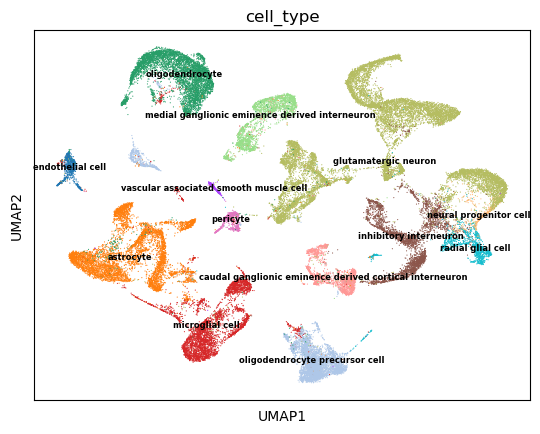

In [6]:
sc.pl.umap(data, color=['cell_type'],legend_loc='on data',legend_fontsize=6)#,save='_mu_ondata.png'

In [7]:
#data.write_h5ad('data_protein_coding_genes.h5ad')

In [8]:
data.X

<45549x17473 sparse matrix of type '<class 'numpy.float32'>'
	with 78306861 stored elements in Compressed Sparse Row format>

In [12]:
data.var.index = data.var['feature_name'].tolist()
data

AnnData object with n_obs × n_vars = 45549 × 17473
    obs: 'author_cell_type', 'age_group', 'donor_id', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'TSS_percentile', 'nucleosome_signal', 'percent_mt', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'organism_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'is_primary_data', 'batch', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'batch_condition', 'citation', 'schema_reference', 'schema_version', 'title', 'cell_type_colors'
    obsm: 'X_joint_wnn_umap', 'X_umap'

In [13]:
data.var

,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type
SAMD11_ENSG00000187634,False,SAMD11_ENSG00000187634,NCBITaxon:9606,gene,1731,protein_coding
NOC2L_ENSG00000188976,False,NOC2L_ENSG00000188976,NCBITaxon:9606,gene,1244,protein_coding
KLHL17_ENSG00000187961,False,KLHL17_ENSG00000187961,NCBITaxon:9606,gene,934,protein_coding
PLEKHN1_ENSG00000187583,False,PLEKHN1_ENSG00000187583,NCBITaxon:9606,gene,2194,protein_coding
PERM1_ENSG00000187642,False,PERM1_ENSG00000187642,NCBITaxon:9606,gene,2765,protein_coding
...,...,...,...,...,...,...
ENSG00000273748.1,False,ENSG00000273748.1,NCBITaxon:9606,gene,372,protein_coding
ENSG00000271254.7,False,ENSG00000271254.7,NCBITaxon:9606,gene,2922,protein_coding
ENSG00000276345.1,False,ENSG00000276345.1,NCBITaxon:9606,gene,740,protein_coding
ENSG00000278817.1,False,ENSG00000278817.1,NCBITaxon:9606,gene,1213,protein_coding


In [14]:
len('ENSG00000273748')

15

In [24]:
data.var_names[0][0:-16]

'SAMD11'

In [26]:
var_new = []
for x in data.var_names:
    if x[0:4] == 'ENSG':
        var_new.append(x)
    elif len(x) < 15:
        var_new.append(x)
    else:
        var_new.append(x[0:-16])
len(var_new)

17473

In [27]:
data.var_names = var_new

In [28]:
data.var_names

Index(['SAMD11', 'NOC2L', 'KLHL17', 'PLEKHN1', 'PERM1', 'HES4', 'ISG15',
       'AGRN', 'C1orf159', 'TTLL10',
       ...
       'ENSG00000278704.1', 'ENSG00000277400.1', 'MAFIP', 'ENSG00000276256.1',
       'ENSG00000278384.1', 'ENSG00000273748.1', 'ENSG00000271254.7',
       'ENSG00000276345.1', 'ENSG00000278817.1', 'ENSG00000277196.4'],
      dtype='object', length=17473)

In [31]:
data.var_names_make_unique() 

In [32]:
#data.write_h5ad('data_protein_coding_genes.h5ad')

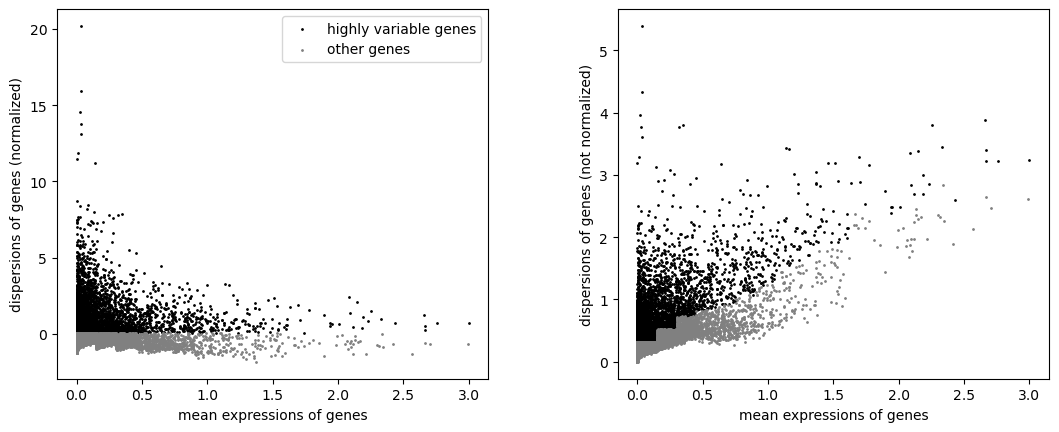

In [34]:
sc.pp.highly_variable_genes(data, n_top_genes=5000)
sc.pl.highly_variable_genes(data)

In [39]:
data = data[:, data.var['highly_variable']]
data

View of AnnData object with n_obs × n_vars = 45549 × 5000
    obs: 'author_cell_type', 'age_group', 'donor_id', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'TSS_percentile', 'nucleosome_signal', 'percent_mt', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'organism_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'is_primary_data', 'batch', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'batch_condition', 'citation', 'schema_reference', 'schema_version', 'title', 'cell_type_colors', 'hvg'
    obsm: 'X_joint_wnn_umap', 'X_umap

In [40]:
data.write('./data_hvg5000.h5ad')

In [41]:
data

View of AnnData object with n_obs × n_vars = 45549 × 5000
    obs: 'author_cell_type', 'age_group', 'donor_id', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'TSS_percentile', 'nucleosome_signal', 'percent_mt', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'organism_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'is_primary_data', 'batch', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'batch_condition', 'citation', 'schema_reference', 'schema_version', 'title', 'cell_type_colors', 'hvg'
    obsm: 'X_joint_wnn_umap', 'X_umap

In [42]:
data.X

<45549x5000 sparse matrix of type '<class 'numpy.float32'>'
	with 21569839 stored elements in Compressed Sparse Row format>

In [43]:
oriData = data
dataSel = oriData.X.T
#dataSel = oriData.X.toarray().T
sampleGenes = oriData.var_names.tolist()
complex = pd.read_table('./ProteinComplex_TFtargets/complex_data_results.txt', header=None,delimiter=': ',engine='python')
mtx_mask_0 = np.zeros((dataSel.shape[0],len(complex)),dtype=int)
for i in range (len(complex)):
    genes = complex.iloc[i][1][2:-2].split("'")
    for j in range (len(sampleGenes)):
        gene = sampleGenes[j]
        if gene in genes:
            mtx_mask_0[j][i] = 1

tf_targets = pd.read_table('./ProteinComplex_TFtargets/tf_data_results.txt', header=None,delimiter=': ',engine='python')
mtx_mask_1 = np.zeros((dataSel.shape[0],len(tf_targets)),dtype=int)
for i in range (len(tf_targets)):
    genes = tf_targets.iloc[i][1][2:-2].split("'")
    for j in range (len(sampleGenes)):
        gene = sampleGenes[j]
        if gene in genes:
            mtx_mask_1[j][i] = 1
s = sum(mtx_mask_0).tolist()
used_labels = []
for i in range(len(s)):
    if s[i] >=5:
        used_labels.append(i)
print(used_labels)
print(len(used_labels))
new_mtx_mask_1 = np.zeros((mtx_mask_0.shape[0], len(used_labels)))
for i in range(len(used_labels)):
    new_mtx_mask_1[:,i] = mtx_mask_0[:,used_labels[i]]
print(new_mtx_mask_1.shape)
new_mtx_mask_1 = pd.DataFrame(new_mtx_mask_1)
new_mtx_mask_1.to_csv('./prior_data_results/complex_use_allgenes_maskedmatrix_filtered_geneNumberOver5.csv',index=False)
s = sum(mtx_mask_1).tolist()
used_labels = []
for i in range(len(s)):
    if s[i] >=5:
        used_labels.append(i)
print(used_labels)
print(len(used_labels))
new_mtx_mask_2 = np.zeros((mtx_mask_1.shape[0], len(used_labels)))
for i in range(len(used_labels)):
    new_mtx_mask_2[:,i] = mtx_mask_1[:,used_labels[i]]
print(new_mtx_mask_2.shape)
new_mtx_mask_2 = pd.DataFrame(new_mtx_mask_2)
new_mtx_mask_2.to_csv('./prior_data_results/TF_use_allgenes_maskedmatrix_filtered_geneNumberOver5.csv',index=False)
pathways = pd.read_table("./PathwayData/pathway_genesTable_Human_symbol.txt", header=None)
mtx_mask_2 = np.zeros((dataSel.shape[0],len(pathways)),dtype=int)
for i in range (len(pathways)):
        pathway = pathways[0][i].split()
        genes = pathway[1:]
        genes = [x[1:-1] for x in genes]
        for j in range (len(sampleGenes)):
            gene = sampleGenes[j]
            if gene in genes:
                mtx_mask_2[j][i] = 1
print('pathway shape: ', mtx_mask_2.shape)
print(sum(mtx_mask_2))
s = sum(mtx_mask_2).tolist()
used_labels = []
total = 0
for i in range(len(s)):
    if s[i] >=5:
        used_labels.append(i)
        total+=s[i]
print(total)
print(used_labels)
print(len(used_labels))
used_names = []
for idx in used_labels:
    pathway_name = pathways[0][idx].split()[0]
    used_names.append(pathway_name[5:])
print(used_names)
print(len(used_names))
used_names = pd.DataFrame(used_names)
used_names.to_csv('./prior_data_results/filterd_pathways_names_used.txt',sep='\t',index=False,header=False)
new_mtx_mask_0 = np.zeros((mtx_mask_2.shape[0], len(used_labels)))
for i in range(len(used_labels)):
    new_mtx_mask_0[:,i] = mtx_mask_2[:,used_labels[i]]
print(new_mtx_mask_0.shape)
print(sum(sum(new_mtx_mask_0)))
new_mtx_mask_0 = pd.DataFrame(new_mtx_mask_0)
print(sum(sum(new_mtx_mask_0.values)))
new_mtx_mask_0.to_csv('./prior_data_results/pathway_use_allgenes_maskedmatrix_filtered_geneNumberOver5.csv',index=False)
import os
path = './PathwayData/pathway_DAG_nodesEdges_file_geneID'
file_name = []
for _, _, files in os.walk(path):
    for n in files:
        if n[0:8] not in file_name:
            file_name.append(n[0:8])
pathway_gene_adj = np.zeros((new_mtx_mask_0.shape[0], new_mtx_mask_0.shape[0]))
file_name = set(file_name)
used_names = set(used_names[0].tolist())
intersec_names = file_name.intersection(used_names)
intersec_names = pd.DataFrame(list(intersec_names))
intersec_names.to_csv('./prior_data_results/pathway_filtered_geneNumberOver5_common_with_KEGGgraph.txt',sep='\t',index=False,header=False)
pathway_gene_adj = np.zeros((new_mtx_mask_0.shape[0], new_mtx_mask_0.shape[0]))
tt = 0
for path_name in sorted(intersec_names[0]):
    file = './PathwayData/pathway_DAG_nodesEdges_file_geneID/%s_edges.txt'%(path_name)
    f = open(file, 'r')
    listOfLines  =  f.readlines()
    t=0
    for line in listOfLines:
        gene_pair = line.split()
        gene_s = gene_pair[0]
        gene_t = gene_pair[1]
        if gene_s != gene_t and gene_s in sampleGenes and gene_t in sampleGenes:
            s_idx = sampleGenes.index(gene_s)
            t_idx = sampleGenes.index(gene_t)
            pathway_gene_adj[s_idx][t_idx] = 1
            t+=1
    print(t)
    tt+=t
print('tt = ', tt)

[69, 134, 135, 136, 137, 188, 201, 255, 265, 301, 377, 414, 483, 489, 490, 1109, 1174, 1389, 1390, 1440, 1524, 1525, 2050, 2478, 2481, 2870, 2889, 2982, 3008, 3184, 3385, 3481]
32
(5000, 32)
[0, 3, 4, 5, 6, 7, 8, 9, 12, 13, 14, 15, 16, 18, 19, 20, 21, 22, 23, 25, 26, 28, 30, 31, 32, 33, 34, 35, 36, 37, 38, 40, 41, 47, 48, 50, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 77, 78, 79, 80, 81, 82, 84, 85, 86, 87, 88, 89, 91, 92, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 106, 107, 108, 110, 111, 112, 113, 114, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 137, 139, 140, 141, 142, 143, 144, 145, 146, 150, 151, 152, 154, 155, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 173, 174, 176, 177, 179, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 210, 213, 214, 215, 216, 218, 220, 221, 224,

In [44]:
pd_pathway_gene_adj = pd.DataFrame(pathway_gene_adj)
pd_pathway_gene_adj.index = sampleGenes
pd_pathway_gene_adj.columns = sampleGenes
from scipy.sparse import csr_matrix
from scipy.sparse import save_npz
sparse_matrix = csr_matrix(pathway_gene_adj)
save_npz('./prior_data_results/pathway_common_with_KEGGgraph_adj_matrix_Sparse.npz', sparse_matrix)
gene_reactome_adg = np.zeros((dataSel.shape[0],dataSel.shape[0]),dtype=int)
gene_reactome_adg = np.zeros((dataSel.shape[0],dataSel.shape[0]),dtype=int)
file = './PathwayData/FIsInGene_070323_with_annotations.txt' #reactome data
f = open(file, 'r')
listOfLines  =  f.readlines()
t=0
for line in listOfLines:
    gene_pair = line.split()
    gene_s = gene_pair[0]
    gene_t = gene_pair[1]
    anno = gene_pair[2]
    #if anno != 'predicted' and gene_s in sampleGenes and gene_t in sampleGenes:
    if gene_s in sampleGenes and gene_t in sampleGenes:
        s_idx = sampleGenes.index(gene_s)
        t_idx = sampleGenes.index(gene_t)
        gene_reactome_adg[s_idx][t_idx] = 1
        gene_reactome_adg[t_idx][s_idx] = 1
        t+=1
gene_reactome_adg = gene_reactome_adg + np.eye(gene_reactome_adg.shape[0])
from scipy.sparse import csr_matrix
from scipy.sparse import save_npz
sparse_matrix = csr_matrix(gene_reactome_adg)
save_npz('./prior_data_results/reactome_gene_interaction_adj_matrix_Sparse.npz', sparse_matrix)

In [ ]:
#以上跑完预处理和encoder连接信息